In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor, OLSInfluence,
)
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
 

In [3]:
grocery=pd.read_excel(r"C:\Users\nihar\Downloads\grocary sales.xlsx")

In [4]:
grocery

,Store,Sales per Square Foot ($),Size of Store (in Sq. Ft.),Advertising Dollars,Number of Products Offered in Store
0,1,837,64796,22000,32920
1,2,748,74179,58000,25034
2,3,744,70298,58000,23989
3,4,853,63367,56000,31095
4,5,839,74412,67000,35055
...,...,...,...,...,...
65,66,812,60021,21000,23946
66,67,864,53108,52000,31507
67,68,924,55101,70000,24530
68,69,767,76177,60000,37966


In [5]:
cols = [
    "Sales per Square Foot ($)",
    "Size of Store (in Sq. Ft.)",
    "Advertising Dollars",
    "Number of Products Offered in Store",
]
grocery[cols].dropna()

,Sales per Square Foot ($),Size of Store (in Sq. Ft.),Advertising Dollars,Number of Products Offered in Store
0,837,64796,22000,32920
1,748,74179,58000,25034
2,744,70298,58000,23989
3,853,63367,56000,31095
4,839,74412,67000,35055
...,...,...,...,...
65,812,60021,21000,23946
66,864,53108,52000,31507
67,924,55101,70000,24530
68,767,76177,60000,37966


In [6]:
y = grocery["Sales per Square Foot ($)"]
X = grocery[[
    "Size of Store (in Sq. Ft.)",
    "Advertising Dollars",
    "Number of Products Offered in Store",
]]

In [7]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [8]:
print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     Sales per Square Foot ($)   R-squared:                       0.383
Model:                                   OLS   Adj. R-squared:                  0.355
Method:                        Least Squares   F-statistic:                     13.65
Date:                       Thu, 23 Jul 2026   Prob (F-statistic):           5.00e-07
Time:                               11:14:42   Log-Likelihood:                -373.65
No. Observations:                         70   AIC:                             755.3
Df Residuals:                             66   BIC:                             764.3
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [9]:
print("R-squared:", round(model.rsquared, 4))
print("Equation:")
print("  Sales/SqFt =", round(model.params["const"], 2))
for name in X.columns[1:]:
    print(f"({round(model.params[name], 6)}) * {name}")

R-squared: 0.3829
Equation:
  Sales/SqFt = 978.13
(-0.002034) * Size of Store (in Sq. Ft.)
(0.002118) * Advertising Dollars
(-0.003698) * Number of Products Offered in Store


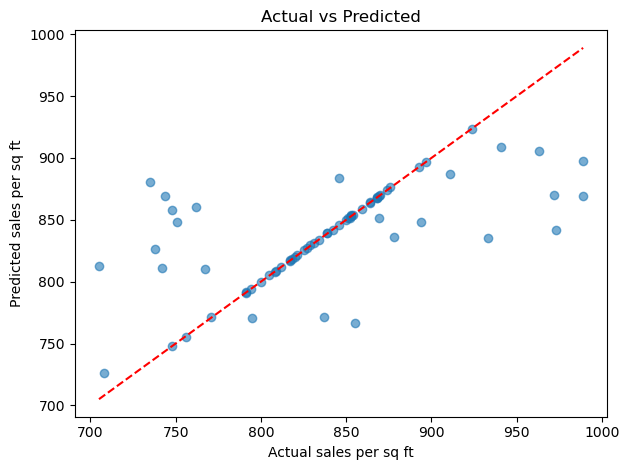

In [10]:
plt.scatter(y, model.fittedvalues, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")  # perfect-prediction line
plt.xlabel("Actual sales per sq ft")
plt.ylabel("Predicted sales per sq ft")
plt.title("Actual vs Predicted")
plt.tight_layout()
#plt.savefig("actual_vs_predicted.png", dpi=120)
#print("\nPlot saved as actual_vs_predicted.png")
plt.show()